# Logistic Regression Classifier
**Data:** Temporally split parquets (`train_t03`, `val_t03`, `test_t03`)  
**Target:** `Results` → `1 = Fail`, `0 = Pass`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, balanced_accuracy_score,
    average_precision_score, brier_score_loss, 
    RocCurveDisplay ,ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader
import joblib

## 2. Load Data

In [2]:
train = pd.read_parquet(DataLoader.transformed('train_t03.parquet'))
val   = pd.read_parquet(DataLoader.transformed('val_t03.parquet'))
test  = pd.read_parquet(DataLoader.transformed('test_t03.parquet'))

print(f'Train: {train.shape}  Val: {val.shape}  Test: {test.shape}')

Train: (109693, 17)  Val: (27483, 17)  Test: (34294, 17)


## 3. Prepare Features & Target

In [3]:
TARGET = 'Results'

X_train, y_train = train.drop(columns=TARGET), train[TARGET]
X_val,   y_val   = val.drop(columns=TARGET),   val[TARGET]
X_test,  y_test  = test.drop(columns=TARGET),  test[TARGET]

for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    ratio = (y==0).sum() / (y==1).sum()
    print(f'{name}: {y.value_counts(normalize=True).mul(100).round(1).to_dict()}  ratio={ratio:.2f}:1')

Train: {0: 70.5, 1: 29.5}  ratio=2.39:1
Val: {0: 69.9, 1: 30.1}  ratio=2.32:1
Test: {0: 51.4, 1: 48.6}  ratio=1.06:1


## 4. Model Definition & Training
Pipeline ensures scaler is fit on train only — no leakage.

In [4]:
# Pipeline ensures scaler is fit on train only — no leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## 5. Hyperparameter Search (C)
Commented out — kept for reference.

In [5]:
# for C in [0.01, 0.1, 1, 10, 100]:
#     p = Pipeline([
#         ('scaler', StandardScaler()),
#         ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=C))
#     ])
#     p.fit(X_train, y_train)
#     proba = p.predict_proba(X_val)[:, 1]
#     print(f'C={C:6}  val ROC-AUC={roc_auc_score(y_val, proba):.4f}')

## 6. Evaluation

In [6]:
def evaluate(model, X, y, split_name):
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    cm           = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # --- derived rates ---
    fnr = fn / (fn + tp)
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    # --- metrics ---
    roc_auc       = roc_auc_score(y, y_pred_proba)
    pr_auc        = average_precision_score(y, y_pred_proba)
    brier         = brier_score_loss(y, y_pred_proba)
    mcc           = matthews_corrcoef(y, y_pred)
    bal_acc       = balanced_accuracy_score(y, y_pred)
    f1_fail       = f1_score(y, y_pred, pos_label=1, zero_division=0)
    f1_pass       = f1_score(y, y_pred, pos_label=0, zero_division=0)
    f1_weighted   = f1_score(y, y_pred, average='weighted', zero_division=0)
    prec_fail     = precision_score(y, y_pred, pos_label=1, zero_division=0)
    recall_fail   = recall_score(y, y_pred, pos_label=1, zero_division=0)

    print(f'=== {split_name} ===')
    print(classification_report(y, y_pred, target_names=['Pass', 'Fail']))

    print('── Key Rates ──')
    print(f'  Sensitivity (Recall Fail):           {tpr:.4f}')
    print(f'  Specificity (Recall Pass):           {tnr:.4f}')
    print(f'  False Negative Rate (missed fails):  {fnr:.4f}')
    print(f'  False Positive Rate (wasted insp.):  {fpr:.4f}')

    print('── Model Quality ──')
    print(f'  ROC-AUC:                             {roc_auc:.4f}')
    print(f'  PR-AUC:                              {pr_auc:.4f}')
    print(f'  Brier Score (lower = better):        {brier:.4f}')
    print(f'  MCC:                                 {mcc:.4f}')
    print(f'  Balanced Accuracy:                   {bal_acc:.4f}')

    print('── Per Class ──')
    print(f'  Precision — Fail:                    {prec_fail:.4f}')
    print(f'  Recall    — Fail:                    {recall_fail:.4f}')
    print(f'  F1        — Fail:                    {f1_fail:.4f}')
    print(f'  F1        — Pass:                    {f1_pass:.4f}')
    print(f'  F1        — Weighted:                {f1_weighted:.4f}')
    print()

    metrics = {
        # counts
        'tp'                 : int(tp),
        'tn'                 : int(tn),
        'fp'                 : int(fp),
        'fn'                 : int(fn),
        # rates
        'sensitivity'        : tpr,
        'specificity'        : tnr,
        'false_negative_rate': fnr,
        'false_positive_rate': fpr,
        # model quality
        'accuracy'           : accuracy_score(y, y_pred),
        'balanced_accuracy'  : bal_acc,
        'roc_auc'            : roc_auc,
        'pr_auc'             : pr_auc,
        'brier_score'        : brier,
        'mcc'                : mcc,
        # per class
        'precision_fail'     : prec_fail,
        'recall_fail'        : recall_fail,
        'f1_fail'            : f1_fail,
        'f1_pass'            : f1_pass,
        'f1_weighted'        : f1_weighted,
    }

    return y_pred_proba, cm, metrics

train_proba, train_cm, train_metrics = evaluate(pipeline, X_train, y_train, 'Train')
val_proba,   val_cm,   val_metrics   = evaluate(pipeline, X_val,   y_val,   'Validation')
test_proba,  test_cm,  test_metrics  = evaluate(pipeline, X_test,  y_test,  'Test')

=== Train ===
              precision    recall  f1-score   support

        Pass       0.87      0.77      0.81     77306
        Fail       0.56      0.72      0.63     32387

    accuracy                           0.75    109693
   macro avg       0.72      0.74      0.72    109693
weighted avg       0.78      0.75      0.76    109693

── Key Rates ──
  Sensitivity (Recall Fail):           0.7217
  Specificity (Recall Pass):           0.7672
  False Negative Rate (missed fails):  0.2783
  False Positive Rate (wasted insp.):  0.2328
── Model Quality ──
  ROC-AUC:                             0.8289
  PR-AUC:                              0.7049
  Brier Score (lower = better):        0.1667
  MCC:                                 0.4601
  Balanced Accuracy:                   0.7444
── Per Class ──
  Precision — Fail:                    0.5649
  Recall    — Fail:                    0.7217
  F1        — Fail:                    0.6338
  F1        — Pass:                    0.8145
  F1     

## 7. Confusion Matrix Plots

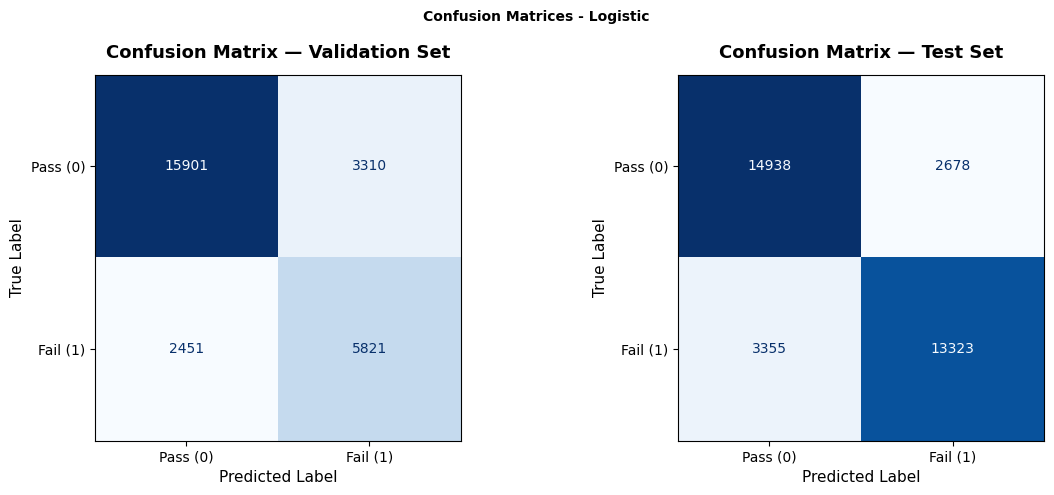

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [val_cm, test_cm],
    ['Validation Set', 'Test Set']
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Pass (0)', 'Fail (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle("Confusion Matrices - Logistic", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig('confusion_matrices_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. ROC Curve & Feature Coefficients

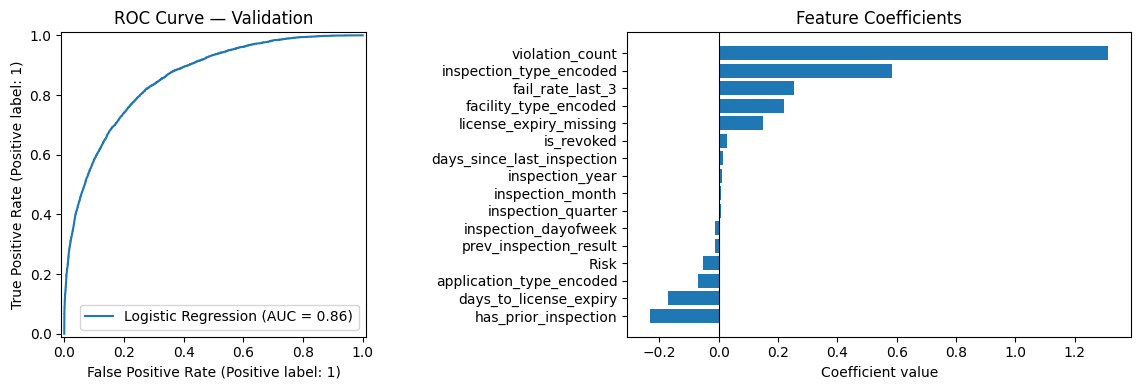

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[0], name='Logistic Regression')
axes[0].set_title('ROC Curve — Validation')

coef_df = pd.DataFrame({
    'feature':     X_train.columns,
    'coefficient': pipeline.named_steps['model'].coef_[0]
}).sort_values('coefficient')

axes[1].barh(coef_df['feature'], coef_df['coefficient'])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients')
axes[1].set_xlabel('Coefficient value')

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [9]:
summary = pd.DataFrame({
    'Split'              : ['Train', 'Val', 'Test'],
    'Accuracy'           : [train_metrics['accuracy'],            val_metrics['accuracy'],            test_metrics['accuracy']],
    'Balanced Accuracy'  : [train_metrics['balanced_accuracy'],   val_metrics['balanced_accuracy'],   test_metrics['balanced_accuracy']],
    'F1 (weighted)'      : [train_metrics['f1_weighted'],         val_metrics['f1_weighted'],         test_metrics['f1_weighted']],
    'F1 — Fail'          : [train_metrics['f1_fail'],             val_metrics['f1_fail'],             test_metrics['f1_fail']],
    'ROC-AUC'            : [train_metrics['roc_auc'],             val_metrics['roc_auc'],             test_metrics['roc_auc']],
    'PR-AUC'             : [train_metrics['pr_auc'],              val_metrics['pr_auc'],              test_metrics['pr_auc']],
    'MCC'                : [train_metrics['mcc'],                 val_metrics['mcc'],                 test_metrics['mcc']],
    'FNR (missed fails)' : [train_metrics['false_negative_rate'], val_metrics['false_negative_rate'], test_metrics['false_negative_rate']],
    'Catch Rate'         : [train_metrics['sensitivity'],         val_metrics['sensitivity'],         test_metrics['sensitivity']],
}).set_index('Split').round(4)

display(summary)

,Accuracy,Balanced Accuracy,F1 (weighted),F1 — Fail,ROC-AUC,PR-AUC,MCC,FNR (missed fails),Catch Rate
Split,,,,,,,,,
Train,0.7537,0.7444,0.7611,0.6338,0.8289,0.7049,0.4601,0.2783,0.7217
Val,0.7904,0.7657,0.7932,0.6690,0.8566,0.7416,0.5175,0.2963,0.7037
Test,0.8241,0.8234,0.8239,0.8154,0.9104,0.9111,0.6480,0.2012,0.7988


## 10. Save Model

In [10]:

models_dir = Path.cwd().parent.parent / 'models'
models_dir.mkdir(exist_ok=True)

joblib.dump(pipeline, models_dir / 'logistic_regression.pkl')
print(f'Model saved to {models_dir / "logistic_regression.pkl"}')

Model saved to /home/engomar/Desktop/Year_04_Spring_2026/Data_Science/CMPS344_Project/Food-Inspection/models/logistic_regression.pkl


## 11. MLflow Logging

In [11]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("../../mlruns")
mlflow.set_experiment("food-inspection-classification")

lr_model = pipeline.named_steps['model']

with mlflow.start_run(run_name="logistic-regression"):

    # --- hyperparameters ---
    mlflow.log_param("C",            lr_model.C)
    mlflow.log_param("class_weight", lr_model.class_weight)
    mlflow.log_param("max_iter",     lr_model.max_iter)
    mlflow.log_param("solver",       lr_model.solver)
    mlflow.log_param("random_state", lr_model.random_state)

    # --- standard metrics ---
    mlflow.log_metric("test_accuracy",          test_metrics['accuracy'])
    mlflow.log_metric("test_balanced_accuracy", test_metrics['balanced_accuracy'])
    mlflow.log_metric("test_f1_weighted",       test_metrics['f1_weighted'])
    mlflow.log_metric("test_f1_fail",           test_metrics['f1_fail'])
    mlflow.log_metric("test_f1_pass",           test_metrics['f1_pass'])
    mlflow.log_metric("test_mcc",               test_metrics['mcc'])
    mlflow.log_metric("test_pr_auc",            test_metrics['pr_auc'])
    mlflow.log_metric("test_brier_score",       test_metrics['brier_score'])
    mlflow.log_metric("test_precision_fail",    test_metrics['precision_fail'])
    mlflow.log_metric("test_recall_fail",       test_metrics['recall_fail'])

    # --- business metrics ---
    mlflow.log_metric("test_false_negative_rate", test_metrics['false_negative_rate'])
    mlflow.log_metric("test_false_positive_rate", test_metrics['false_positive_rate'])
    mlflow.log_metric("test_failing_catch_rate",  test_metrics['sensitivity'])

    # --- val + test roc ---
    mlflow.log_metric("val_roc_auc",  val_metrics['roc_auc'])
    mlflow.log_metric("test_roc_auc", test_metrics['roc_auc'])

    # --- model artifact (full pipeline incl. scaler) ---
    mlflow.sklearn.log_model(pipeline, artifact_path="model")

    # --- plot artifacts ---
    mlflow.log_artifact("logistic_regression_results.png")
    mlflow.log_artifact("confusion_matrices_logistic.png")

    run_id = mlflow.active_run().info.run_id
    print(f"Run logged. ID: {run_id}")

/home/engomar/.cache/pypoetry/virtualenvs/science-the-data-CK6af-Of-py3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/engomar/.cache/pypoetry/virtualenvs/science-the-data-CK6af-Of-py3.13/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/04 21:55:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 21:55:39 WARNING mlflow.sklearn: Saving scikit-learn models

Run logged. ID: 1764acf7cc21445093525bfb5a9f0339
